# Day 3 / 7 — Temporal Attention (Multi-Head Attention)
### `src/models/temporal_attention.py` — using your Day 1 + Day 2 settings

**Carried forward:**
```python
# Day 1
window_size = 30, n_assets = 10, all features on, normalize_method = 'zscore'
# Day 2
vsn_hidden_dim = 64, lstm_hidden_dim = 32, lstm_num_layers = 3, dropout = 0.1
```

⚠️ **One thing to flag before we start:** you picked `lstm_hidden_dim=32` (much smaller than the `128` default) and `lstm_num_layers=3` (deeper than default). In Day 2's Experiment C you likely saw that going from 2→3 layers widens the train/val gap on this small dataset (only ~630 training windows). A small `lstm_hidden_dim=32` partly compensates by cutting parameter count — worth keeping an eye on whether that combination overfits again today, now that attention adds even more parameters on top.

**Today's model:** `TemporalAttentionBlock` = Multi-Head Self-Attention (with sinusoidal positional encoding) + residual/LayerNorm + Feed-Forward Network. It sits right after the LSTM in your diagram, turning the LSTM's day-by-day output sequence into `h_temp` by letting the model decide **which of the 30 days matter most**, instead of just using the LSTM's last hidden state.

Since `mha_dim` must equal `lstm_hidden_dim` (your config enforces this, and the layer literally requires `d_model % num_heads == 0`), today's `d_model = 32`. That constrains which `num_heads` values are even valid — must be a divisor of 32 (1, 2, 4, 8, 16, 32). We'll test **1, 2, 4 (baseline), 8**.


## Step 0 — Setup (same zip as before)

In [1]:
from google.colab import files
import os

if not os.path.exists('/content/Regime detection portfolio.zip') and not os.path.exists('/content/project'):
    uploaded = files.upload()


In [2]:
import os, zipfile, glob

ZIP_CANDIDATES = glob.glob('/content/*.zip')
PROJECT_DIR = '/content/project'

if not os.path.exists(PROJECT_DIR):
    assert ZIP_CANDIDATES, "No zip found in /content — upload it first."
    with zipfile.ZipFile(ZIP_CANDIDATES[0], 'r') as z:
        z.extractall(PROJECT_DIR)

ROOT = None
for dirpath, _, filenames in os.walk(PROJECT_DIR):
    if 'main.py' in filenames:
        ROOT = dirpath
        break
assert ROOT is not None
print("Project root:", ROOT)


Project root: /content/project/Regime detection portfolio


In [3]:
!pip install -q torch pandas numpy scikit-learn matplotlib seaborn

In [4]:
import sys
sys.path.insert(0, ROOT)
os.chdir(ROOT)

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns

from src.config.config import get_config, DATA_RAW_DIR
from src.data.data_loader import CSEDataLoader
from src.data.preprocessor import Preprocessor
from src.models.vsn_lstm import VSNLSTM
from src.models.temporal_attention import TemporalAttentionBlock

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", device)


Device: cuda


## Step 1 — Rebuild windows (Day 1) and target (Day 2)

In [5]:
DAY1 = dict(window_size=30, normalize_method='zscore', n_assets=10)
DAY2 = dict(vsn_hidden_dim=64, lstm_hidden_dim=32, lstm_num_layers=3, dropout=0.1)

loader = CSEDataLoader(raw_data_dir=DATA_RAW_DIR)
prices, volumes = loader.load_prices_and_volumes(n_assets=DAY1['n_assets'])

preprocessor = Preprocessor(window_size=DAY1['window_size'], normalize_method=DAY1['normalize_method'])
features = preprocessor.engineer_features(prices, volumes)
normalized = preprocessor.fit_normalize(features)
windows = preprocessor.create_windows(normalized.values)
feature_names = list(features.columns)

avg_log_return = np.log(prices / prices.shift(1)).mean(axis=1)
target_next = avg_log_return.shift(-1)
window_dates = features.index[DAY1['window_size'] - 1:]
targets = target_next.reindex(window_dates)

valid_mask = targets.notna().values
windows_valid = windows[valid_mask]
targets_valid = targets.values[valid_mask].astype(np.float32)

n = windows_valid.shape[0]
n_train = int(n * 0.8)
X_train, X_val = windows_valid[:n_train], windows_valid[n_train:]
y_train, y_val = targets_valid[:n_train], targets_valid[n_train:]
print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | d_model (=lstm_hidden_dim): {DAY2['lstm_hidden_dim']}")


Train: 628 | Val: 158 | d_model (=lstm_hidden_dim): 32


## Step 2 — Training probe: VSN+LSTM (frozen at your Day 2 settings) → Temporal Attention → linear head

Same idea as Day 2: predict next-day average market return, but now the LSTM output sequence passes through `TemporalAttentionBlock` before the last-timestep representation goes to the prediction head. The attention weights themselves are also returned so we can visualize them.


In [6]:
def train_probe_attn(mha_num_heads=4, ffn_dim=256, mha_dropout=0.1,
                      epochs=30, lr=1e-3, batch_size=32, seed=42, verbose=False):
    torch.manual_seed(seed)
    np.random.seed(seed)

    n_features = X_train.shape[2]
    d_model = DAY2['lstm_hidden_dim']

    encoder = VSNLSTM(
        n_features=n_features,
        vsn_hidden_dim=DAY2['vsn_hidden_dim'],
        lstm_hidden_dim=d_model,
        lstm_num_layers=DAY2['lstm_num_layers'],
        dropout=DAY2['dropout'],
    ).to(device)

    attn_block = TemporalAttentionBlock(
        d_model=d_model,
        num_heads=mha_num_heads,
        ffn_dim=ffn_dim,
        dropout=mha_dropout,
    ).to(device)

    head = nn.Linear(d_model, 1).to(device)

    params = list(encoder.parameters()) + list(attn_block.parameters()) + list(head.parameters())
    n_params = sum(p.numel() for p in params)
    optimizer = torch.optim.Adam(params, lr=lr)
    loss_fn = nn.MSELoss()

    X_train_t = torch.FloatTensor(X_train)
    y_train_t = torch.FloatTensor(y_train)
    X_val_t = torch.FloatTensor(X_val).to(device)
    y_val_t = torch.FloatTensor(y_val).to(device)

    n_train_samples = X_train_t.shape[0]
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        encoder.train(); attn_block.train(); head.train()
        perm = torch.randperm(n_train_samples)
        epoch_loss = 0.0
        for i in range(0, n_train_samples, batch_size):
            idx = perm[i:i+batch_size]
            xb = X_train_t[idx].to(device)
            yb = y_train_t[idx].to(device)

            lstm_out, _, _ = encoder(xb)
            attn_out, _ = attn_block(lstm_out)
            pred = head(attn_out[:, -1, :]).squeeze(-1)
            loss = loss_fn(pred, yb)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * xb.shape[0]

        train_losses.append(epoch_loss / n_train_samples)

        encoder.eval(); attn_block.eval(); head.eval()
        with torch.no_grad():
            lstm_out_val, _, _ = encoder(X_val_t)
            attn_out_val, attn_weights_val = attn_block(lstm_out_val)
            pred_val = head(attn_out_val[:, -1, :]).squeeze(-1)
            val_losses.append(loss_fn(pred_val, y_val_t).item())

        if verbose and (epoch % 5 == 0 or epoch == epochs - 1):
            print(f"  epoch {epoch:3d} | train MSE {train_losses[-1]:.6f} | val MSE {val_losses[-1]:.6f}")

    # attn_weights_val: (B, heads, T, T) -- average over batch and heads for a summary view
    mean_attn = attn_weights_val.mean(dim=(0, 1)).detach().cpu().numpy()  # (T, T)

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'final_val_loss': val_losses[-1],
        'n_params': n_params,
        'mean_attn': mean_attn,
    }

print("train_probe_attn() ready.")


train_probe_attn() ready.


## Step 3 — Baseline run (`mha_num_heads=4`, `ffn_dim=256`, `mha_dropout=0.1`)

  epoch   0 | train MSE 0.059327 | val MSE 0.017050
  epoch   5 | train MSE 0.002549 | val MSE 0.000180
  epoch  10 | train MSE 0.001916 | val MSE 0.000457
  epoch  15 | train MSE 0.001574 | val MSE 0.000211
  epoch  20 | train MSE 0.001354 | val MSE 0.000228
  epoch  25 | train MSE 0.001132 | val MSE 0.000231
  epoch  29 | train MSE 0.001065 | val MSE 0.000361


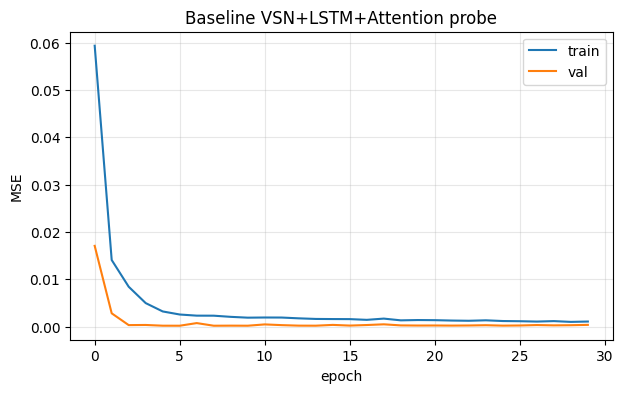

Params: 1,533,917 | Final val MSE: 0.000361


In [7]:
baseline = train_probe_attn(mha_num_heads=4, ffn_dim=256, mha_dropout=0.1, epochs=30, verbose=True)

plt.figure(figsize=(7,4))
plt.plot(baseline['train_losses'], label='train')
plt.plot(baseline['val_losses'], label='val')
plt.xlabel('epoch'); plt.ylabel('MSE'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Baseline VSN+LSTM+Attention probe')
plt.show()

print(f"Params: {baseline['n_params']:,} | Final val MSE: {baseline['final_val_loss']:.6f}")


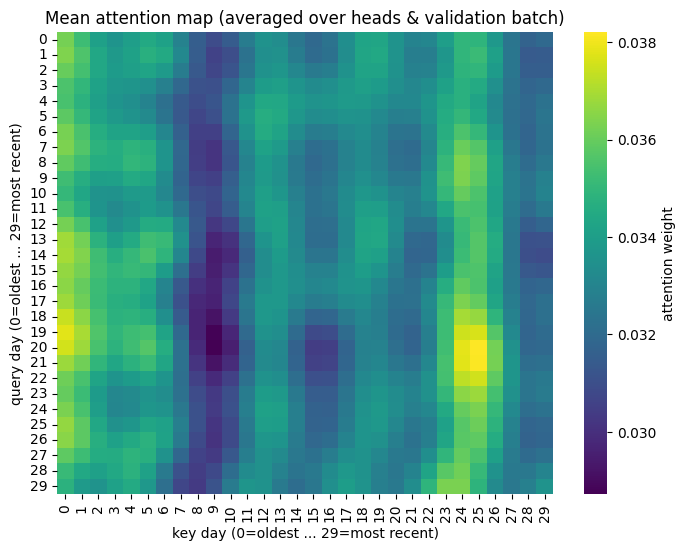

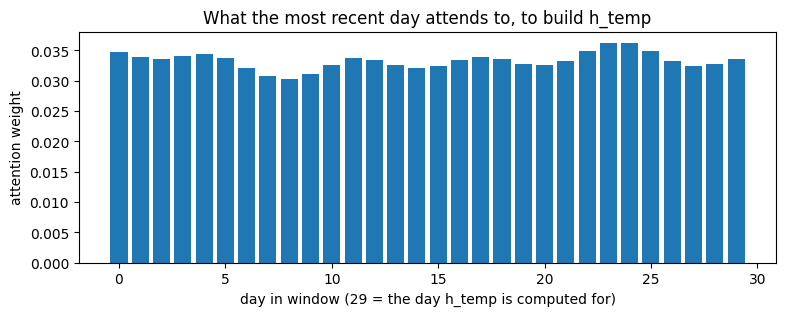

In [8]:
# Which past days does the model attend to most when forming the representation for the LAST day in the window?
plt.figure(figsize=(8,6))
sns.heatmap(baseline['mean_attn'], cmap='viridis', cbar_kws={'label': 'attention weight'})
plt.xlabel('key day (0=oldest ... 29=most recent)')
plt.ylabel('query day (0=oldest ... 29=most recent)')
plt.title('Mean attention map (averaged over heads & validation batch)')
plt.show()

# Focus on the last row: what the FINAL day attends to across the 30-day window
last_day_attn = baseline['mean_attn'][-1]
plt.figure(figsize=(9,3))
plt.bar(range(len(last_day_attn)), last_day_attn)
plt.xlabel('day in window (29 = the day h_temp is computed for)')
plt.ylabel('attention weight')
plt.title("What the most recent day attends to, to build h_temp")
plt.show()


**Your task:** does the last row show a clear peak (e.g. the model leaning heavily on the most recent 1-3 days, "recency bias"), or is it fairly spread across the window (suggesting it's picking up longer-range regime patterns)? Either is a valid finding — just note which one you see.

> Your answer:


## Experiment A — `mha_num_heads`

Must divide `d_model=32`. Try **1, 2, 4 (baseline), 8**. More heads = each head attends over a narrower slice of the 32-dim representation (`d_k = d_model / num_heads`), potentially specializing in different temporal patterns; fewer heads = each head sees more of the representation at once.


mha_num_heads=1  (d_k=32)
mha_num_heads=2  (d_k=16)
mha_num_heads=4  (d_k=8)
mha_num_heads=8  (d_k=4)


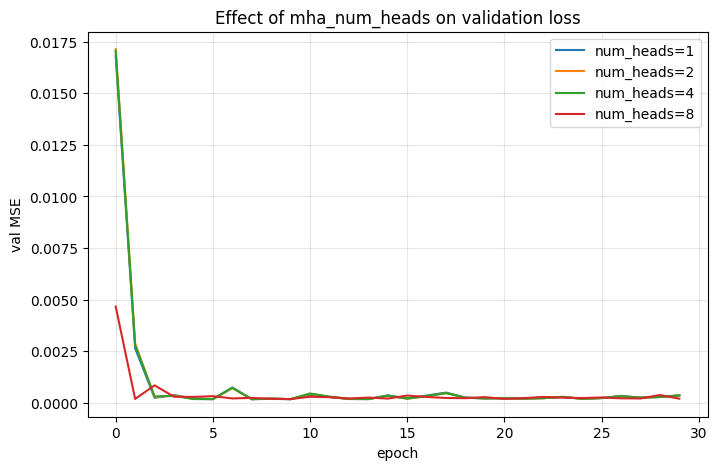

,num_heads,d_k,final_val_mse,n_params
0,1,32,0.000361,1533917
1,2,16,0.000370,1533917
2,4,8,0.000361,1533917
3,8,4,0.000204,1533917


In [9]:
head_counts = [1, 2, 4, 8]
head_results = {}
for h in head_counts:
    print(f"mha_num_heads={h}  (d_k={32 // h})")
    head_results[h] = train_probe_attn(mha_num_heads=h, ffn_dim=256, mha_dropout=0.1, epochs=30)

plt.figure(figsize=(8,5))
for h, res in head_results.items():
    plt.plot(res['val_losses'], label=f'num_heads={h}')
plt.xlabel('epoch'); plt.ylabel('val MSE'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Effect of mha_num_heads on validation loss')
plt.show()

pd.DataFrame([{'num_heads': h, 'd_k': 32 // h, 'final_val_mse': r['final_val_loss'], 'n_params': r['n_params']} for h, r in head_results.items()])


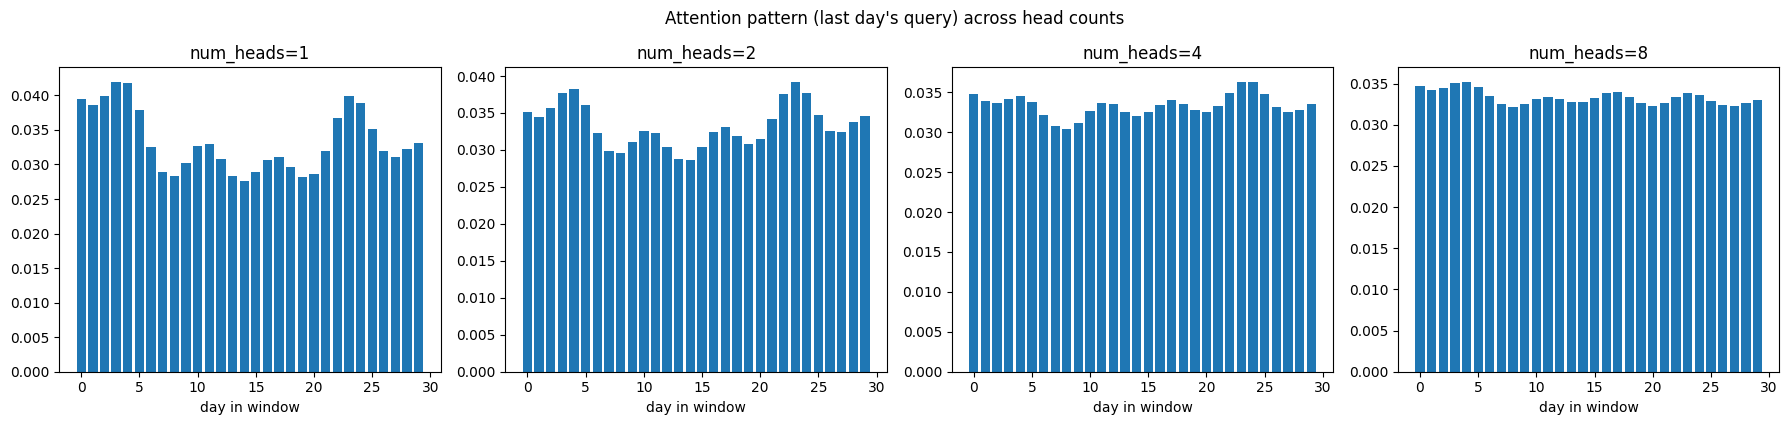

In [10]:
fig, axes = plt.subplots(1, len(head_counts), figsize=(4.5*len(head_counts), 4))
for ax, h in zip(axes, head_counts):
    last_row = head_results[h]['mean_attn'][-1]
    ax.bar(range(len(last_row)), last_row)
    ax.set_title(f'num_heads={h}')
    ax.set_xlabel('day in window')
plt.tight_layout()
plt.suptitle('Attention pattern (last day\'s query) across head counts', y=1.05)
plt.show()


**Your task:** with `d_model=32`, `num_heads=8` gives each head only `d_k=4` dimensions to work with — quite narrow. Does val loss actually degrade at 8, or is it still fine? Compare the attention *shape* across head counts too — does more heads make the pattern noisier/more scattered?

> Your answer:


## Experiment B — `ffn_dim`

The feed-forward network inside the attention block (`Linear → GELU → Linear`) that processes each day's representation independently after attention mixes information across days. Try **64, 128, 256 (baseline), 512**.


ffn_dim=64
ffn_dim=128
ffn_dim=256
ffn_dim=512


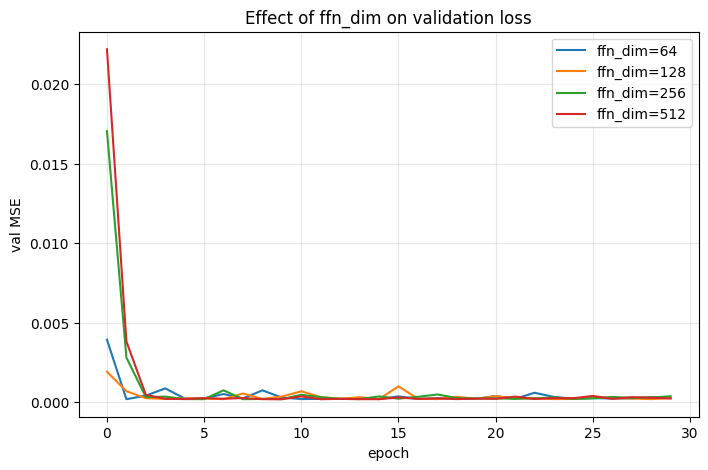

,ffn_dim,final_val_mse,n_params
0,64,0.000255,1521437
1,128,0.000250,1525597
2,256,0.000361,1533917
3,512,0.000221,1550557


In [11]:
ffn_dims = [64, 128, 256, 512]
ffn_results = {}
for f in ffn_dims:
    print(f"ffn_dim={f}")
    ffn_results[f] = train_probe_attn(mha_num_heads=4, ffn_dim=f, mha_dropout=0.1, epochs=30)

plt.figure(figsize=(8,5))
for f, res in ffn_results.items():
    plt.plot(res['val_losses'], label=f'ffn_dim={f}')
plt.xlabel('epoch'); plt.ylabel('val MSE'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Effect of ffn_dim on validation loss')
plt.show()

pd.DataFrame([{'ffn_dim': f, 'final_val_mse': r['final_val_loss'], 'n_params': r['n_params']} for f, r in ffn_results.items()])


**Your task:** `ffn_dim=512` adds a lot of parameters relative to your tiny `d_model=32` representation and ~630 training samples. Does it help, or is this where you start seeing overfitting (train loss keeps improving, val loss stalls or worsens)?

> Your answer:


## Experiment C — `mha_dropout`

Applied to attention weights and inside the FFN. Try **0.0, 0.1 (baseline), 0.3, 0.5**.


mha_dropout=0.0
mha_dropout=0.1
mha_dropout=0.3
mha_dropout=0.5


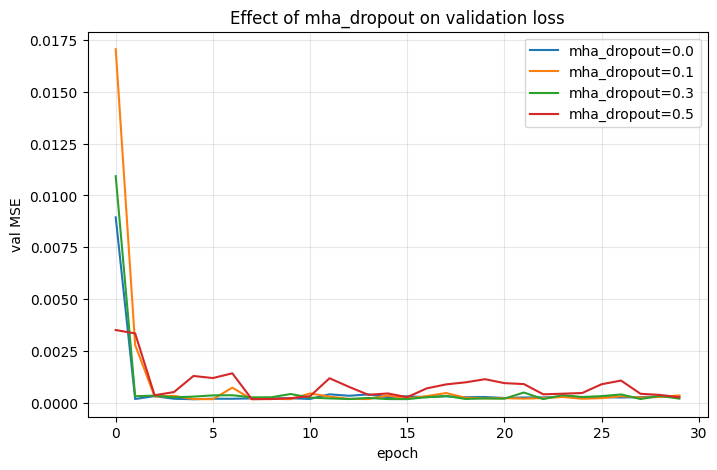

,mha_dropout,final_val_mse
0,0.0,0.000309
1,0.1,0.000361
2,0.3,0.000206
3,0.5,0.000271


In [12]:
dropout_vals = [0.0, 0.1, 0.3, 0.5]
dropout_results = {}
for p in dropout_vals:
    print(f"mha_dropout={p}")
    dropout_results[p] = train_probe_attn(mha_num_heads=4, ffn_dim=256, mha_dropout=p, epochs=30)

plt.figure(figsize=(8,5))
for p, res in dropout_results.items():
    plt.plot(res['val_losses'], label=f'mha_dropout={p}')
plt.xlabel('epoch'); plt.ylabel('val MSE'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Effect of mha_dropout on validation loss')
plt.show()

pd.DataFrame([{'mha_dropout': p, 'final_val_mse': r['final_val_loss']} for p, r in dropout_results.items()])


**Your task:** given your Day 2 combination (`lstm_num_layers=3`, small `lstm_hidden_dim=32`) already risks overfitting, does higher `mha_dropout` here noticeably help close the train/val gap, or does the model stay data-starved regardless?

> Your answer:


## Wrap-up

`h_temp` (the latent market state going to the Actor/Critic in your diagram) has dimension **`lstm_hidden_dim` = 32** — the output of today's attention block. Log your Day 3 choices below.


In [13]:
day3_choices = {
    'mha_num_heads': None,   # e.g. 4
    'ffn_dim': None,         # e.g. 256
    'mha_dropout': None,     # e.g. 0.1
}
import json
print(json.dumps(day3_choices, indent=2))
with open('/content/day3_choices.json', 'w') as f:
    json.dump(day3_choices, f, indent=2)


{
  "mha_num_heads": null,
  "ffn_dim": null,
  "mha_dropout": null
}


**Next up — Day 4:** Macro Graph Prior (`src/models/macro_graph_prior.py`) — a GNN/GAT that injects an inductive bias about relationships between assets/macro variables. You'll tune `gnn_hidden_dim`, `gnn_num_heads` (GAT attention heads), and `gnn_num_layers`, and see how the graph structure changes what gets fed alongside the temporal path into the Actor/Critic.
